# Customer Segmentation using K-Means Clustering

## Data Analytics Project

**Submitted By:** Rahul Gaonkar

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option('display.max_columns', None)

# Plot Style
sns.set(style="whitegrid")

In [2]:
# Load datasets
df_09_10 = pd.read_csv("online_retail_09_10.csv", encoding='ISO-8859-1')
df_10_11 = pd.read_csv("online_retail_10_11.csv", encoding='ISO-8859-1')

# Merge datasets
df = pd.concat([df_09_10, df_10_11], ignore_index=True)

In [3]:
df.head()

,ï»¿InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/2009 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/2009 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/2009 7:45,1.25,13085.0,United Kingdom


In [4]:
df.tail()

,ï»¿InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,12/9/2011 12:50,18.00,12680.0,France


In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1067371
Columns : 8


In [6]:
df.columns

Index(['ï»¿InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [7]:
df.dtypes

ï»¿InvoiceNo     object
StockCode        object
Description      object
Quantity          int64
InvoiceDate      object
UnitPrice       float64
CustomerID      float64
Country          object
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   ï»¿InvoiceNo  1067371 non-null  object 
 1   StockCode     1067371 non-null  object 
 2   Description   1062989 non-null  object 
 3   Quantity      1067371 non-null  int64  
 4   InvoiceDate   1067371 non-null  object 
 5   UnitPrice     1067371 non-null  float64
 6   CustomerID    824364 non-null   float64
 7   Country       1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [25]:
df.rename(columns={'ï»¿InvoiceNo': 'InvoiceNO'}, inplace=True)

In [26]:
missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(df)) * 100
})

missing_df

,Missing Values,Percentage
Invoice,0,0.0
StockCode,0,0.0
Description,0,0.0
Quantity,0,0.0
InvoiceDate,0,0.0
UnitPrice,0,0.0
CustomerID,0,0.0
Country,0,0.0


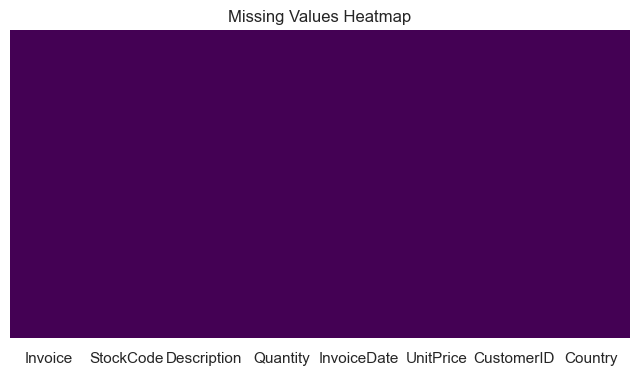

In [27]:
plt.figure(figsize=(8,4))

sns.heatmap(df.isnull(),
            cbar=False,
            yticklabels=False,
            cmap="viridis")

plt.title("Missing Values Heatmap")
plt.show()

In [28]:
df = df.dropna(subset=['CustomerID'])

In [29]:
df.reset_index(drop=True, inplace=True)

In [30]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [31]:
df = df.drop_duplicates()

In [32]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [ ]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [34]:
df = df[df['Quantity'] > 0]

In [37]:
df = df[df['UnitPrice'] > 0]

In [36]:
print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [38]:
print(df.shape)

(779425, 8)


In [39]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [40]:
df['InvoiceDate'].dtype

dtype('<M8[ns]')

In [41]:
# Descriptive statistics for numerical columns
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,779425.000000,779425,779425.000000,779425.000000
mean,13.489370,2011-01-03 01:44:42.593475584,3.218488,15320.360461
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000
25%,2.000000,2010-07-02 14:39:00,1.250000,13971.000000
50%,6.000000,2010-12-02 14:09:00,1.950000,15247.000000
75%,12.000000,2011-08-01 13:44:00,3.750000,16794.000000
max,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000
std,145.855814,NaN,29.676140,1695.692775


In [42]:
# Total Purchase Amount
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [43]:
average_purchase = df['TotalAmount'].mean()

print("Average Purchase Value :", round(average_purchase,2))

Average Purchase Value : 22.29


In [44]:
purchase_frequency = df.groupby('CustomerID')['Invoice'].nunique()

purchase_frequency.head()

CustomerID
12346.0    12
12347.0     8
12348.0     5
12349.0     4
12350.0     1
Name: Invoice, dtype: int64

In [45]:
print("Average Purchase Frequency :", round(purchase_frequency.mean(),2))

Average Purchase Frequency : 6.29


In [46]:
customer_clv = df.groupby('CustomerID')['TotalAmount'].sum()

customer_clv.head()

CustomerID
12346.0    77556.46
12347.0     4921.53
12348.0     2019.40
12349.0     4428.69
12350.0      334.40
Name: TotalAmount, dtype: float64

In [47]:
print("Average Customer Lifetime Value :", round(customer_clv.mean(),2))

Average Customer Lifetime Value : 2955.9


In [48]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


In [49]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalAmount': 'sum'
})

In [50]:
rfm.columns = ['Recency','Frequency','Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [51]:
rfm.shape

(5878, 3)

In [52]:
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,342.280000
50%,96.000000,3.000000,867.740000
75%,380.000000,7.000000,2248.305000
max,739.000000,398.000000,580987.040000


In [53]:
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

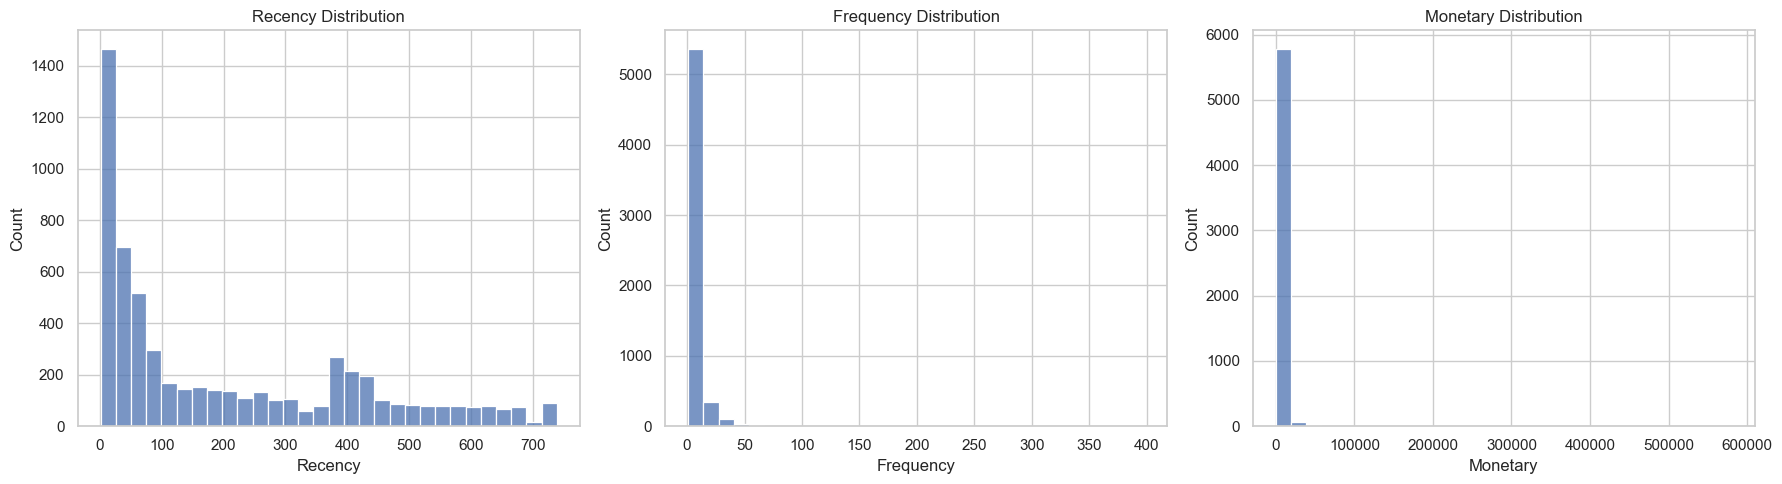

In [54]:
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.histplot(rfm['Recency'], bins=30)
plt.title("Recency Distribution")

plt.subplot(1,3,2)
sns.histplot(rfm['Frequency'], bins=30)
plt.title("Frequency Distribution")

plt.subplot(1,3,3)
sns.histplot(rfm['Monetary'], bins=30)
plt.title("Monetary Distribution")

plt.tight_layout()
plt.show()

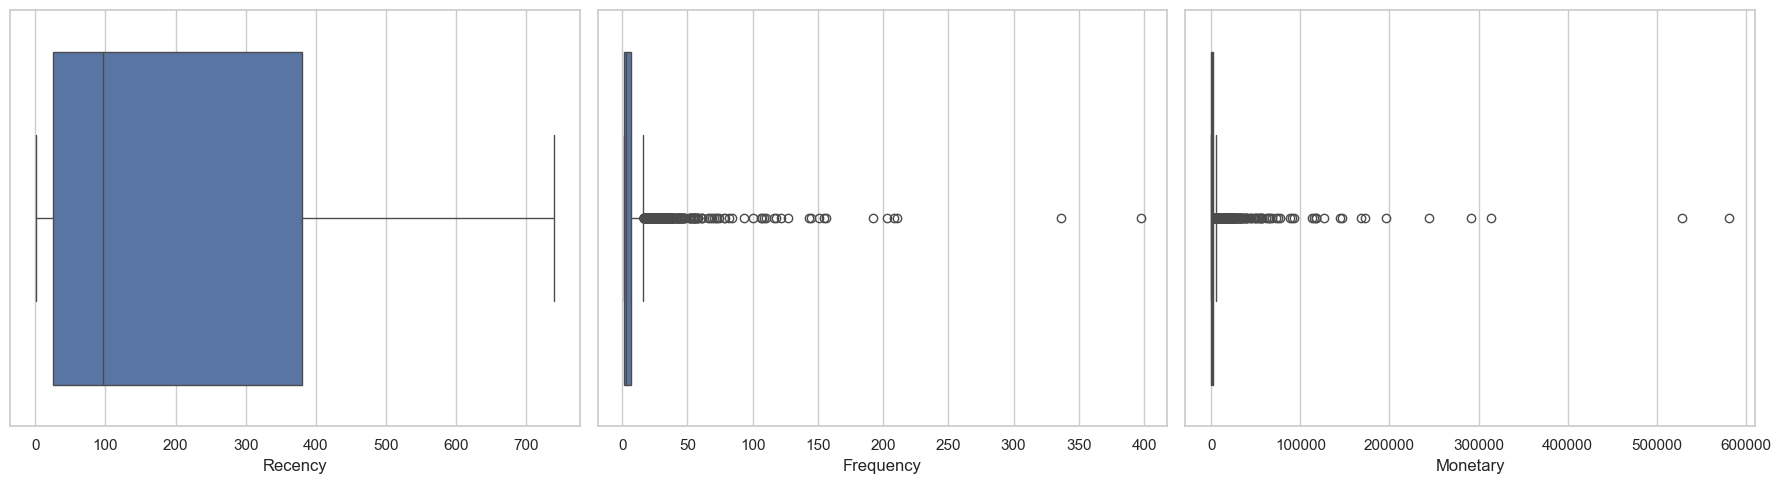

In [55]:
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.boxplot(x=rfm['Recency'])

plt.subplot(1,3,2)
sns.boxplot(x=rfm['Frequency'])

plt.subplot(1,3,3)
sns.boxplot(x=rfm['Monetary'])

plt.tight_layout()
plt.show()

In [56]:
# Select RFM features
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

rfm_features.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [57]:
# Standardize the data
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

# Convert back to DataFrame
rfm_scaled = pd.DataFrame(rfm_scaled,
                          columns=rfm_features.columns,
                          index=rfm_features.index)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,0.595584,0.438998,5.166378
12347.0,-0.952279,0.131502,0.136127
12348.0,-0.603532,-0.099120,-0.064857
12349.0,-0.871064,-0.175994,0.101996
12350.0,0.519146,-0.406616,-0.181549


In [58]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i,
                    random_state=42,
                    n_init=10)

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

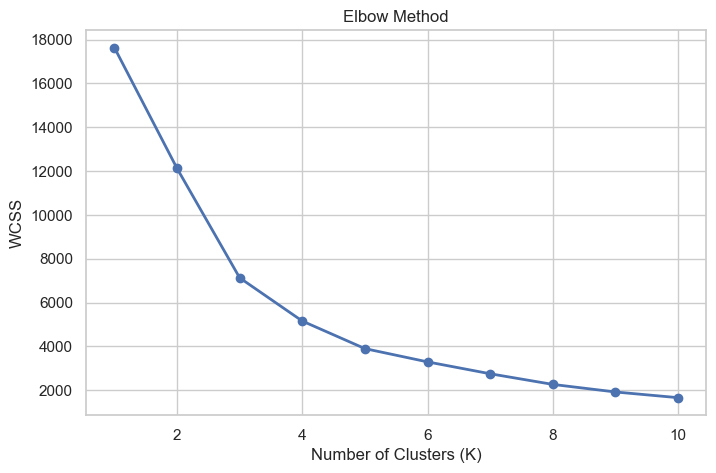

In [59]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss,
         marker='o',
         linewidth=2)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)

plt.show()

In [60]:
optimal_k = 4

In [61]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,12,77556.46,0
12347.0,2,8,4921.53,0
12348.0,75,5,2019.40,0
12349.0,19,4,4428.69,0
12350.0,310,1,334.40,1


In [62]:
rfm['Cluster'].value_counts()

Cluster
0    3838
1    1998
3      38
2       4
Name: count, dtype: int64

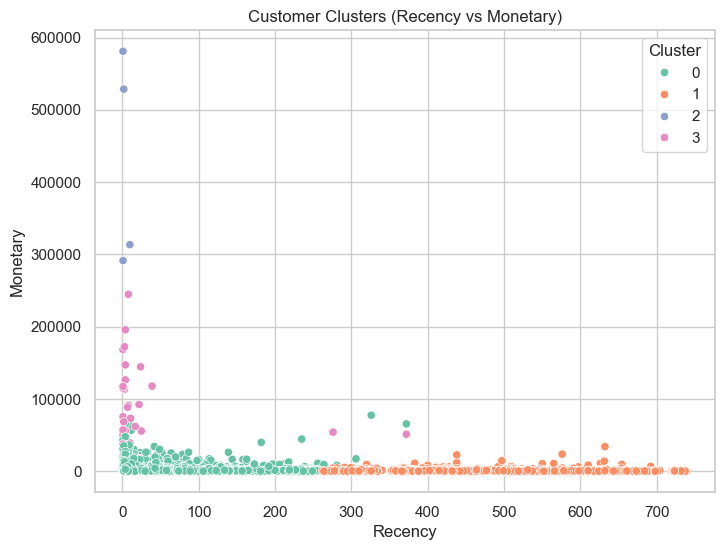

In [63]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.title("Customer Clusters (Recency vs Monetary)")
plt.show()

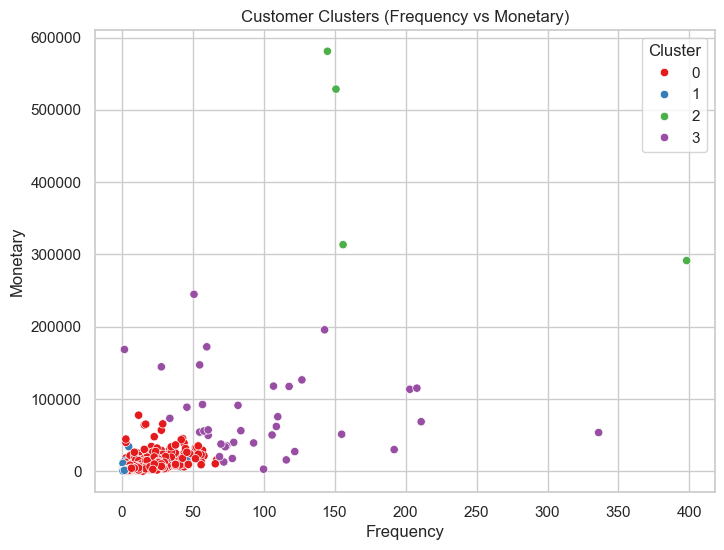

In [64]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set1'
)

plt.title("Customer Clusters (Frequency vs Monetary)")
plt.show()

In [65]:
cluster_profile = rfm.groupby('Cluster').mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,67.054455,7.267848,2921.080058
1,463.032032,2.212212,748.536998
2,3.500000,212.500000,428611.997500
3,24.263158,100.131579,77728.265579


In [66]:
cluster_profile.round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,67.05,7.27,2921.08
1,463.03,2.21,748.54
2,3.50,212.50,428612.00
3,24.26,100.13,77728.27


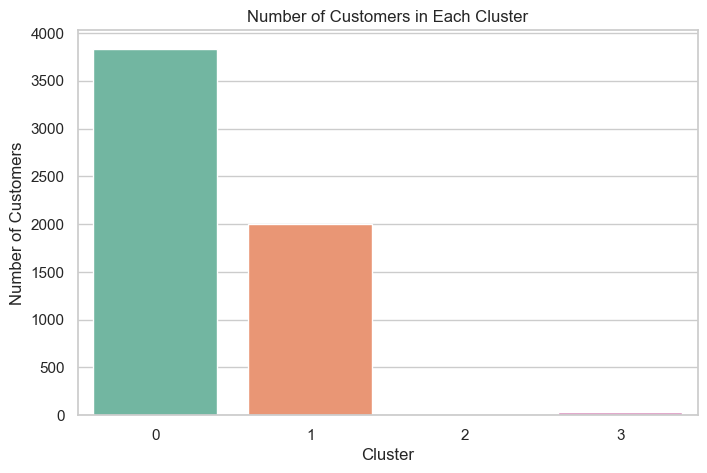

In [67]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm,
    x='Cluster',
    palette='Set2'
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

In [68]:
rfm.to_csv("Customer_Segments.csv")

# Insights and Marketing Recommendations

After performing K-Means clustering on the RFM (Recency, Frequency, Monetary) features, customers were segmented into different groups based on their purchasing behaviour. Each segment represents customers with similar buying patterns and can be targeted with specific marketing strategies.

### Cluster 0 – High Value Customers
- These customers purchase frequently and spend the most money.
- They are the most valuable customers for the business.

**Recommended Marketing Actions:**
- Offer premium memberships and exclusive discounts.
- Provide early access to new products.
- Reward them through loyalty and referral programs.

---

### Cluster 1 – Loyal Customers
- These customers make regular purchases and contribute consistently to sales.
- They have good potential for long-term retention.

**Recommended Marketing Actions:**
- Send personalized product recommendations.
- Offer reward points and cashback programs.
- Encourage repeat purchases with special offers.

---

### Cluster 2 – At-Risk Customers
- These customers have not purchased for a long time and are likely to stop buying.
- Their purchase frequency and spending have decreased.

**Recommended Marketing Actions:**
- Launch win-back campaigns.
- Send reminder emails and personalized discount coupons.
- Offer limited-time promotions to encourage another purchase.

---

### Cluster 3 – Occasional Customers
- These customers purchase infrequently and spend a moderate amount.
- They have the potential to become loyal customers with proper engagement.

**Recommended Marketing Actions:**
- Promote seasonal discounts and bundle offers.
- Send personalized email campaigns.
- Recommend related products to increase purchase frequency.

---

## Overall Business Insight

Customer segmentation using RFM analysis and K-Means clustering helps identify different customer groups based on purchasing behaviour. By implementing targeted marketing strategies for each segment, businesses can improve customer retention, increase sales, enhance customer satisfaction, and optimize marketing resources.